<a href="https://colab.research.google.com/github/sri2-star/Optimization-techniques-for-AI/blob/main/Sri_Optimization_techniques_for_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Linear Programming problems

Linear Programming Problem -Graphical Method-Maximization

Optimal Solution x =2.0,y=2.0,Z=10.0


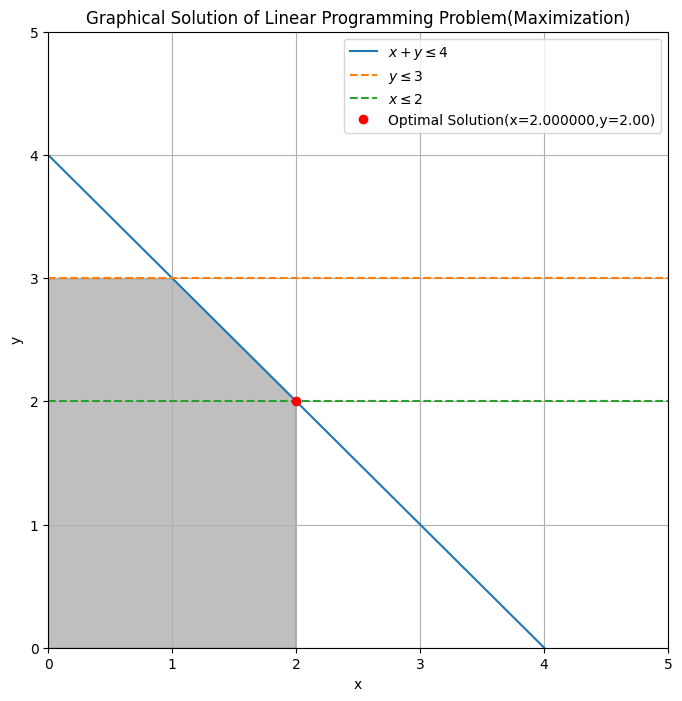

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
c=[-3,-2]
A=[[1,1],[1,0],[0,1]]
b=[4,2,3]
x_bounds=(0,None)
y_bounds=(0,None)
res=linprog(c,A_ub=A,b_ub=b,bounds=[x_bounds,y_bounds],method='highs')
x_opt,y_opt=res.x
z_opt=-res.fun
print(f"Optimal Solution x ={x_opt},y={y_opt},Z={z_opt}")
x=np.linspace(0,5,400)
y1 = 4-x
y2 = np.ones_like(x)*3
y3 = 2*np.ones_like(x)

plt.figure(figsize=(8,8))
plt.plot(x, y1, label=r'$x + y \leq 4$')
plt.plot(x, y2, label=r'$y \leq 3$', linestyle='--')
plt.plot(x, y3, label=r'$x \leq 2$', linestyle='--')

plt.fill_between(x,np.minimum(y1,y2),where=(x<=2),color='gray',alpha=0.5)
plt.plot(x_opt,y_opt,'ro',label=f'Optimal Solution(x={x_opt:2f},y={y_opt:.2f})')
plt.xlim(0,5)
plt.ylim(0,5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Graphical Solution of Linear Programming Problem(Maximization)')
plt.legend()
plt.grid(True)
plt.show()


Optimal Solution x =15.0,y=0.0,Z=75.0


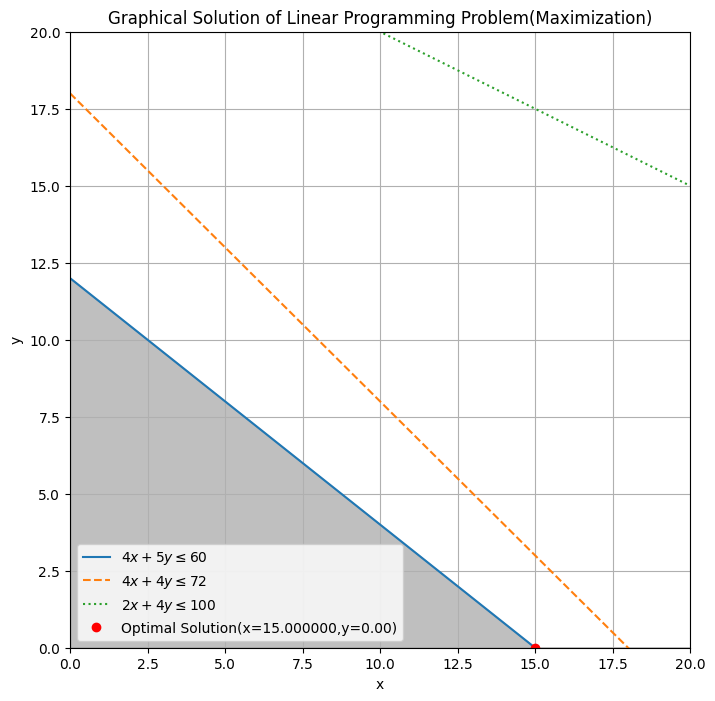

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
c=[-5,-3]
A=[[4,5],[4,4],[2,4]]
b=[60,72,100]
x_bounds=(0,None)
y_bounds=(0,None)
res=linprog(c,A_ub=A,b_ub=b,bounds=[x_bounds,y_bounds],method='highs')
x_opt,y_opt=res.x
z_opt=-res.fun
print(f"Optimal Solution x ={x_opt},y={y_opt},Z={z_opt}")
x=np.linspace(0,20,400)
y1 = (60 - 4*x)/5
y2 = (72 - 4*x)/4
y3 = (100 - 2*x)/4

plt.figure(figsize=(8,8))
plt.plot(x, y1, label=r'$4x + 5y \leq 60$')
plt.plot(x, y2, label=r'$4x + 4y \leq 72$', linestyle='--')
plt.plot(x, y3, label=r'$2x + 4y \leq 100$', linestyle=':')

y_feasible = np.minimum(np.minimum(y1, y2), y3)
y_feasible = np.maximum(y_feasible, 0)
plt.fill_between(x, y_feasible, 0, where=(y_feasible>=0), color='gray', alpha=0.5)

plt.plot(x_opt,y_opt,'ro',label=f'Optimal Solution(x={x_opt:2f},y={y_opt:.2f})')
plt.xlim(0,20)
plt.ylim(0,20)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Graphical Solution of Linear Programming Problem(Maximization)')
plt.legend()
plt.grid(True)
plt.show()

LPP-Constraint Optimization

In [ ]:
import numpy as np
from scipy.optimize import linprog
c = [1,-2, 1]
A = [
[1,2,-2],
[1,0,- 1],[2,-1,2]
]
b = [4, 3,2]
x_bounds = (0, None)
y_bounds = (0, None)
z_bounds = (0, None)
result = linprog(c, A_ub=A, b_ub=b,bounds=[x_bounds, y_bounds,z_bounds],
method='highs')
print('Optimal value:', -result.fun)
print('Values of x:', result.x)

Optimal value: 8.0
Values of x: [0. 6. 4.]


LPP-Graphical Method-Minimization

Optimal solution: x = 3.6, y = 1.4, Z = 320.0


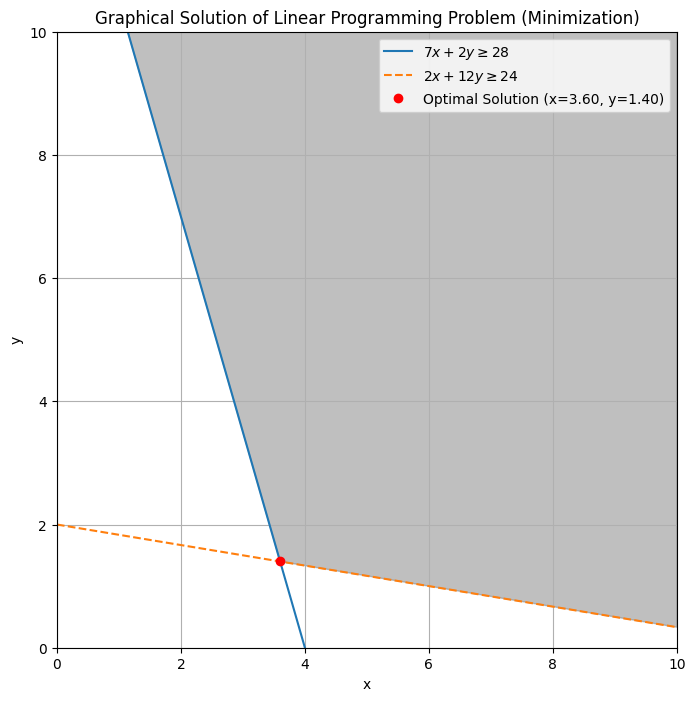

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
c = [50, 100]
A = [[-7, -2],
[-2, -12]]
b = [-28, -24]
x_bounds = (0, None)
y_bounds = (0, None)
res = linprog(c, A_ub=A, b_ub=b, bounds=[x_bounds, y_bounds], method='highs')
x_opt, y_opt = res.x
z_opt = res.fun
print(f"Optimal solution: x = {x_opt}, y = {y_opt}, Z = {z_opt}")
x = np.linspace(0, 10, 400)
y1 = (28 - 7*x) / 2
y2 = (24 - 2*x) /12
plt.figure(figsize=(8, 8))
plt.plot(x, y1, label=r'$7x + 2y \geq 28$')
plt.plot(x, y2, label=r'$2x + 12y \geq 24$', linestyle='--')
y_feasible = np.maximum(y1, y2)
plt.fill_between(x, y_feasible, 10, color='grey', alpha=0.5)
plt.plot(x_opt, y_opt, 'ro', label=f'Optimal Solution (x={x_opt:.2f}, y={y_opt:.2f})')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Graphical Solution of Linear Programming Problem (Minimization)')
plt.legend()
plt.grid(True)
plt.show()

# 2.Transportation Problems

Balanced Transportation Problem

In [ ]:
import numpy as np
from scipy.optimize import linprog
def transportation_problem(supply, demand, costs):
    if sum(supply) != sum(demand):
        if sum(supply) < sum(demand):
            diff = sum(demand) - sum(supply)
            supply.append(diff)
            costs = np.hstack((costs, np.zeros((costs.shape[0], 1))))
        else:
            diff = sum(supply) - sum(demand)
            demand.append(diff)
            costs = np.vstack((costs, np.zeros((1, costs.shape[1]))))
    num_sources = len(supply)
    num_destinations = len(demand)
    A_eq = np.zeros((num_sources + num_destinations,
                     num_sources * num_destinations))
    for i in range(num_sources):
        A_eq[i, i * num_destinations:(i + 1) * num_destinations] = 1
    for j in range(num_destinations):
        A_eq[num_sources + j, j::num_destinations] = 1
    b_eq = np.array(supply + demand)
    c = costs.flatten()
    result = linprog(c, A_eq=A_eq, b_eq=b_eq, method='highs')
    allocation = result.x.reshape(num_sources, num_destinations)
    total_cost = result.fun
    return allocation, total_cost
supply =[50,40,60]
demand = [30,70,50]
costs = np.array([
    [4,8,8],
    [2,7,6],
    [3,4,2],
])
allocation, total_cost = transportation_problem(supply, demand, costs)
print("Optimal Allocation:")
print(allocation)
print("Total Cost:", total_cost)

Optimal Allocation:
[[ 0. 50.  0.]
 [30. 10.  0.]
 [ 0. 10. 50.]]
Total Cost: 670.0


Unbalanced Transportation Problem

In [ ]:
import numpy as np
from scipy.optimize import linprog
def transportation_problem(supply, demand, costs):
    if sum(supply) != sum(demand):
        if sum(supply) < sum(demand):
            diff = sum(demand) - sum(supply)
            supply.append(diff)
            extra_row = np.zeros((1, costs.shape[1]))
            costs = np.vstack((costs, extra_row))
        else:
            diff = sum(supply) - sum(demand)
            demand.append(diff)
            extra_column = np.zeros((costs.shape[0], 1))
            costs = np.hstack((costs, extra_column))
    num_sources = len(supply)
    num_destinations = len(demand)
    A_eq = np.zeros((num_sources + num_destinations, num_sources * num_destinations))
    for i in range(num_sources):
        A_eq[i, i * num_destinations : (i + 1) * num_destinations] = 1
    for j in range(num_destinations):
        A_eq[num_sources + j, j::num_destinations] = 1
    b_eq = np.concatenate((supply, demand))
    c = costs.flatten()
    result = linprog(c, A_eq=A_eq, b_eq=b_eq, method='highs')
    allocation = result.x.reshape(num_sources, num_destinations)
    total_cost = result.fun
    return allocation, total_cost
supply = [7, 9, 10]
demand = [5, 8, 7, 14]
costs = np.array([
    [19, 30, 50, 10],
    [70, 30, 40, 60],
    [40, 8, 70, 20]
])
allocation, total_cost = transportation_problem(supply, demand, costs)
print("Optimal Allocation:")
print(allocation)
print("Total Cost:", total_cost)


Optimal Allocation:
[[0. 0. 0. 7.]
 [0. 2. 7. 0.]
 [0. 6. 0. 4.]
 [5. 0. 0. 3.]]
Total Cost: 538.0


# 3.Assignment problems

Assignment problem-Balanced

In [ ]:
import numpy as np
from scipy.optimize import linear_sum_assignment

cost_matrix = np.array([
  [13,8,16,18,19],
  [9,15,24,9,12],
  [12,9,4,4,4],
  [6,12,10,8,13],
  [15,17,18,12,20]
])
row_ind, col_ind = linear_sum_assignment(cost_matrix)
print("Cost Matrix:")
print(cost_matrix)
total_cost = 0
print("\nOptimal Assignment:")
for r,c in zip(row_ind,col_ind):
  print(f"Person {r+1} → Job {c+1} | Cost = {cost_matrix[r][c]}")
  total_cost += cost_matrix[r][c]
print("\nMinimum Total Cost =", total_cost)


Cost Matrix:
[[13  8 16 18 19]
 [ 9 15 24  9 12]
 [12  9  4  4  4]
 [ 6 12 10  8 13]
 [15 17 18 12 20]]

Optimal Assignment:
Person 1 → Job 2 | Cost = 8
Person 2 → Job 5 | Cost = 12
Person 3 → Job 3 | Cost = 4
Person 4 → Job 1 | Cost = 6
Person 5 → Job 4 | Cost = 12

Minimum Total Cost = 42


In [ ]:
import numpy as np
from scipy.optimize import linear_sum_assignment

cost_matrix = np.array([
  [5,7,11,6],
  [8,5,9,6],
  [4,7,10,7],
  [10,4,8,3]
])
row_ind, col_ind = linear_sum_assignment(cost_matrix)
print("Cost Matrix:")
print(cost_matrix)
total_cost = 0
print("\nOptimal Assignment:")
for r,c in zip(row_ind,col_ind):
  print(f"Person {r+1} → Job {c+1} | Cost = {cost_matrix[r][c]}")
  total_cost += cost_matrix[r][c]
print("\nMinimum Total Cost =", total_cost)


Cost Matrix:
[[ 5  7 11  6]
 [ 8  5  9  6]
 [ 4  7 10  7]
 [10  4  8  3]]

Optimal Assignment:
Person 1 → Job 4 | Cost = 6
Person 2 → Job 2 | Cost = 5
Person 3 → Job 1 | Cost = 4
Person 4 → Job 3 | Cost = 8

Minimum Total Cost = 23


3. Assignment problem-Unbalanced

In [ ]:
import numpy as np
from scipy.optimize import linear_sum_assignment
cost_matrix = np.array([
      [4,3,6,2,7],
      [10,12,11,14,16],
      [4,3,2,1,5],
      [8,7,6,9,6]
])
print("Original Cost Matrix:")
print(cost_matrix)
rows, cols = cost_matrix.shape
if rows > cols:
      dummy = np.zeros((rows, rows - cols))
      cost_matrix = np.hstack((cost_matrix, dummy))
      print("\nAdded Dummy Column(s)")
elif cols > rows:
  dummy = np.zeros((cols - rows, cols))
  cost_matrix = np.vstack((cost_matrix, dummy))
  print("\nAdded Dummy Row(s)")
print("\nBalanced Cost Matrix:")
print(cost_matrix)
row_ind, col_ind = linear_sum_assignment(cost_matrix)

total_cost = 0
print("\nOptimal Assignment:")
for r, c in zip(row_ind, col_ind):
  if r < rows and c < cols:
    print(f"Person {r+1} → Job {c+1} | Cost = {cost_matrix[r][c]}")
    total_cost += cost_matrix[r][c]
  elif r >= rows:
    print(f"Person {r+1} (Dummy) → Job {c+1}")
  elif c >= cols:
    print(f"Person {r+1} → Job {c+1} (Dummy)")
print("\nMinimum Total Cost =", total_cost)

Original Cost Matrix:
[[ 4  3  6  2  7]
 [10 12 11 14 16]
 [ 4  3  2  1  5]
 [ 8  7  6  9  6]]

Added Dummy Row(s)

Balanced Cost Matrix:
[[ 4.  3.  6.  2.  7.]
 [10. 12. 11. 14. 16.]
 [ 4.  3.  2.  1.  5.]
 [ 8.  7.  6.  9.  6.]
 [ 0.  0.  0.  0.  0.]]

Optimal Assignment:
Person 1 → Job 2 | Cost = 3.0
Person 2 → Job 1 | Cost = 10.0
Person 3 → Job 4 | Cost = 1.0
Person 4 → Job 3 | Cost = 6.0
Person 5 (Dummy) → Job 5

Minimum Total Cost = 20.0


# 4.INTEGER PROGRAMMING PROBLEM- BRANCH AND BOUND METHOD

In [ ]:
import numpy as np
from scipy.optimize import linprog
from queue import Queue
def solve_lp(c, A, b, bounds):
  res = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')
  return res
def branch_and_bound(c, A, b, bounds):
  Q = Queue()
  Q.put((c, A, b, bounds))
  best_solution = None
  best_value = float('-inf')
  while not Q.empty():
    current_problem = Q.get()
    res = solve_lp(*current_problem)
    if res.success:
      value = -res.fun
      solution = res.x
      if value > best_value:
        if all(np.isclose(solution, np.round(solution))):
          best_value = value
          best_solution = solution
        else:
          for i in range(len(solution)):
            if not np.isclose(solution[i],np.round(solution[i])):
              lower_bounds = list(current_problem[3])
              upper_bounds = list(current_problem[3])
              lower_bounds[i] = (lower_bounds[i][0], np.floor(solution[i]))
              upper_bounds[i] = (np.ceil(solution[i]), upper_bounds[i][1])
              Q.put((current_problem[0], current_problem[1], current_problem[2], lower_bounds))
              Q.put((current_problem[0], current_problem[1], current_problem[2], upper_bounds))
              break
  return best_solution, best_value


c = [-4, -3]

A = [[2, 1],
     [1, 2]]
b = [8, 6]
bounds = [(0, None), (0, None)]
solution, value = branch_and_bound(c, A, b, bounds)
print("Optimal solution:", solution)
print("Optimal value:", value)


Optimal solution: [ 4. -0.]
Optimal value: 16.0


# 5.Dynamic Programming Problems

Knapsack Problem

In [ ]:
def knapsack(weights, values, W):
  n = len(weights)
  dp = [[0 for _ in range(W + 1)] for _ in range(n + 1)]
  for i in range(n + 1):
    for w in range(W + 1):
      if i == 0 or w == 0:
        dp[i][w] = 0
      elif weights[i-1] <= w:
        dp[i][w] = max(values[i-1] + dp[i-1][w-weights[i-1]],dp[i-1][w])
      else:
        dp[i][w] = dp[i-1][w]
  return dp[n][W]
weights = [1, 3, 4, 5]
values = [1, 4, 5, 7]
W = 7
print("Maximum value:", knapsack(weights, values, W))

Maximum value: 9


Subset Sum Problem

In [ ]:
def subset_sum(arr, sum):
  n = len(arr)
  dp = [[False for _ in range(sum + 1)] for _ in range(n + 1)]
  for i in range(n + 1):
    dp[i][0] = True
  for i in range(1, n + 1):
    for s in range(1, sum + 1):
      if arr[i-1] <= s:
        dp[i][s] = dp[i-1][s] or dp[i-1][s - arr[i-1]]
      else:
        dp[i][s] = dp[i-1][s]
  return dp[n][sum]

arr = [3, 34, 4, 12, 5, 2]
sum = 9
print("Subset with given sum exists:", subset_sum(arr, sum))

Subset with given sum exists: True


Longest Common Subsequence Problem

In [ ]:
def lcs(X,Y):
  m=len(X)
  n=len(Y)
  dp=[[0 for _ in range(n+1)]for _ in range(m+1)]
  for i in range(m+1):
    for j in range(n+1):
      if i==0 or j==0:
        dp[i][j]=0
      elif X[i-1]==Y[j-1]:
        dp[i][j]=dp[i-1][j-1]+1
      else:
        dp[i][j]=max(dp[i-1][j],dp[i][j-1])
  return dp[m][n]
X = "AGGTAB"
Y = "GXTXAYB"
print("Length of LCS:", lcs(X, Y))

Length of LCS: 4


#6.STOCHASTIC GRADIENT DESCENT ALGORITHM

In [ ]:
import numpy as np
def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs=1000):
  n_samples, n_features = X.shape
  weights = np.zeros(n_features)
  for epoch in range(epochs):
    for i in range(n_samples):
      gradient = (np.dot(X[i], weights) - y[i]) * X[i]
      weights -= learning_rate * gradient
  return weights
if __name__ == "__main__":
  np.random.seed(0)
  X = 2 * np.random.rand(100, 1)
  y = 4 + 3 * X + np.random.randn(100, 1)
  X_b = np.c_[np.ones((100, 1)), X]
  y = y.ravel()
  learning_rate = 0.01
  epochs = 1000
  weights = stochastic_gradient_descent(X_b, y, learning_rate, epochs)
  print("Weights:", weights)

Weights: [4.16464189 2.90371342]


# 7.UNCONSTRAINED OPTIMIZATION-NONLINEAR LEAST SQUARES

Exponential Decay Model

In [ ]:
import numpy as np
from scipy.optimize import least_squares
def model(x, t):
  return x[0] * np.exp(-x[1] * t)
def residual(x, t, y):
  return model(x, t) - y
np.random.seed(123)
t = np.linspace(0, 1, 50)
y_true = [2.0, 0.5]
y = model(y_true, t) + 0.1 * np.random.randn(50)
x0 = [1.0, 1.0]
result = least_squares(residual, x0, args=(t, y))
print("Optimized parameters:", result.x)

Optimized parameters: [1.98254019 0.47917343]


Logistic Growth Model

In [ ]:
import numpy as np
from scipy.optimize import least_squares

def model(x, t):
  return x[0] / (1 + np.exp(-x[1] * (t - x[2])))
def residual(x, t, y):
  return model(x, t) - y
np.random.seed(456)
t = np.linspace(0, 5, 100)
y_true = [5.0, 0.8, 3.0]
y = model(y_true, t) + 0.1 * np.random.randn(100)
x0 = [1.0, 1.0, 1.0]
result = least_squares(residual, x0, args=(t, y))
print("Optimized parameters:", result.x)

Optimized parameters: [5.19893281 0.77489624 3.10139266]


Sum of Sine Waves Model

In [ ]:
import numpy as np
from scipy.optimize import least_squares
def model(x, t):
  return (x[0] * np.sin(x[1] * t + x[2]) +
  x[3] * np.sin(x[4] * t + x[5]))
def residual(x, t, y):
  return model(x, t) - y
np.random.seed(789)
t = np.linspace(0, 10, 200)
y_true = [2.0, 0.5, 1.0, 1.0, 2.0, 2.5]
y = model(y_true, t) + 0.1 * np.random.randn(200)
x0 = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
result = least_squares(residual, x0, args=(t, y))
print("Optimized parameters:", result.x)

Optimized parameters: [0.97587131 0.54470271 0.77416988 0.97586095 0.54475034 0.77408607]


#8.Kuhn-Tucker conditions - Lagrangian Multiplier method

Kuhn–Tucker (KKT) Conditions for Optimization

In [ ]:
from scipy.optimize import minimize
import numpy as np

def objective(x):
  return -(2*x[0]**2 + x[1]**2 + x[0]*x[1] + x[0] + x[1])
def constraint(x):
  return 1 - (x[0]**2 + x[1]**2)
initial_guess = [0.5, 0.5]
constraint_obj = {'type': 'ineq', 'fun': constraint}
result = minimize(objective, initial_guess, constraints=constraint_obj)
opt_solution = result.x
opt_value = result.fun
from scipy.optimize import approx_fprime
gradient_f = approx_fprime(opt_solution, objective, 1e-6)
gradient_g = approx_fprime(opt_solution, constraint, 1e-6)
lambda_val = -np.dot(gradient_f, gradient_g) / np.dot(gradient_g, gradient_g)
stationarity = np.allclose(gradient_f + lambda_val * gradient_g, [0, 0], atol=1e-3)
primal_feasibility = constraint(opt_solution) >= 0
dual_feasibility = lambda_val >= 0
complementary_slackness = abs(lambda_val * constraint(opt_solution)) < 1e-3
print("Optimal Solution:", opt_solution)
print("Optimal Value:", opt_value)
print("Lambda:", lambda_val)
print("Stationarity:", stationarity)
print("Primal Feasibility:", primal_feasibility)
print("Dual Feasibility:", dual_feasibility)
print("Complementary Slackness:", complementary_slackness)

Optimal Solution: [0.86602541 0.49999999]
Optimal Value: -3.549038107178365
Lambda: -2.8660245629577084
Stationarity: True
Primal Feasibility: False
Dual Feasibility: False
Complementary Slackness: True


Lagrangian Multiplier Method for Constrained Optimization

In [ ]:
from scipy.optimize import minimize

def objective(x):
  return -x[0] * x[1]
def constraint1(x):
  return 10 - (x[0]**2 + x[1]**2)
def constraint2(x):
  return x[0] - x[1]
x0 = [1, 1]
constraints = [{'type': 'ineq', 'fun': constraint1}, {'type': 'eq', 'fun': constraint2}]
result = minimize(objective, x0, method='SLSQP', constraints=constraints)
print("Optimized Values:", result.x)
print("Optimal Value:", result.fun)

Optimized Values: [2.23606798 2.23606798]
Optimal Value: -5.000000001987865


KKT Conditions using Lagrangian Method

In [ ]:
from scipy.optimize import minimize
import numpy as np

def objective(x):
    return -(2*x[0]**2 + x[1]**2 + x[0]*x[1] + x[0] + x[1])
def constraint(x):
  return 1 - (x[0]**2 + x[1]**2)

x0 = [0.5, 0.5]
cons = {'type': 'ineq', 'fun': constraint}
result = minimize(objective, x0, constraints=cons)
opt_solution = result.x
opt_value = result.fun
from scipy.optimize import approx_fprime
grad_f = approx_fprime(opt_solution, objective, 1e-6)
grad_g = approx_fprime(opt_solution, constraint, 1e-6)
lambda_ = -np.dot(grad_f, grad_g) / np.dot(grad_g, grad_g)
stationarity = np.allclose(grad_f + lambda_ * grad_g, [0, 0], atol=1e-3)
primal_feasibility = constraint(opt_solution) >= 0
dual_feasibility = lambda_ >= 0
complementary_slackness = abs(lambda_ * constraint(opt_solution)) < 1e-3
print("Optimal Solution:", opt_solution)
print("Optimal Value:", opt_value)
print("Lambda:", lambda_)
print("Stationarity:", stationarity)
print("Primal Feasibility:", primal_feasibility)
print("Dual Feasibility:", dual_feasibility)
print("Complementary Slackness:", complementary_slackness)

Optimal Solution: [0.86602541 0.49999999]
Optimal Value: -3.549038107178365
Lambda: -2.8660245629577084
Stationarity: True
Primal Feasibility: False
Dual Feasibility: False
Complementary Slackness: True


# 9.CPM -ANALYSIS

Earliest start times: {'A': 0, 'B': 3, 'C': 3, 'D': 5, 'E': 7, 'F': 10}
Earliest finish times: {'A': 3, 'B': 5, 'C': 7, 'D': 7, 'E': 10, 'F': 11}
Latest start times: {'A': 0, 'B': 3, 'C': 3, 'D': 5, 'E': 7, 'F': 10}
Latest finish times: {'A': 3, 'B': 5, 'C': 7, 'D': 7, 'E': 10, 'F': 11}
Critical path: ['A', 'B', 'C', 'D', 'E', 'F']


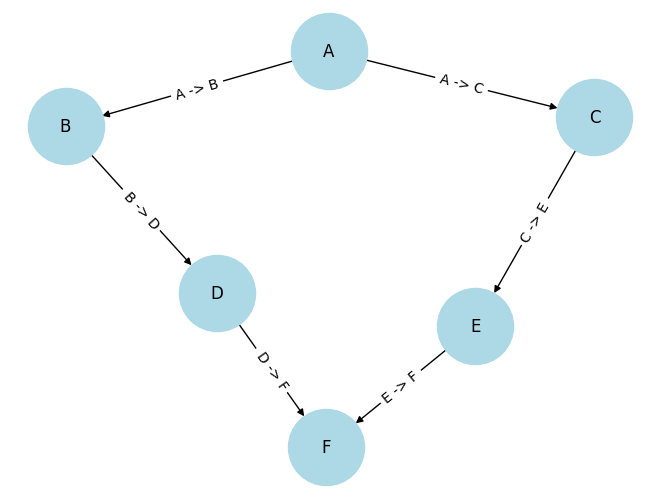

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
tsk = {
    'A': {'dur': 3, 'deps': []},
    'B': {'dur': 2, 'deps': ['A']},
    'C': {'dur': 4, 'deps': ['A']},
    'D': {'dur': 2, 'deps': ['B']},
    'E': {'dur': 3, 'deps': ['C']},
    'F': {'dur': 1, 'deps': ['D', 'E']}
}

g = nx.DiGraph()

for t, d in tsk.items():
    g.add_node(t, duration=d['dur'])

for t, d in tsk.items():
    for dp in d['deps']:
        g.add_edge(dp, t)

t_ord = list(nx.topological_sort(g))

es = {t: 0 for t in t_ord}
ef = {t: 0 for t in t_ord}

for t in t_ord:
    ef[t] = es[t] + g.nodes[t]['duration']
    for s in g.successors(t):
        es[s] = max(es[s],ef[t])

lf = {t: ef[t] for t in t_ord}
ls = {t: es[t] for t in t_ord}

for t in reversed(t_ord):
    for p in g.predecessors(t):
        lf[p] = min(lf[p], ls[t])
        ls[p] = lf[p] - g.nodes[p]['duration']

cp = [t for t in t_ord if es[t] == ls[t]]

print('Earliest start times:', es)
print('Earliest finish times:', ef)
print('Latest start times:', ls)
print('Latest finish times:', lf)
print('Critical path:', cp)

ps = nx.spring_layout(g)
nx.draw(g, ps, with_labels=True, node_size=3000, node_color='lightblue')
lbl = nx.get_node_attributes(g, 'duration')
nx.draw_networkx_edge_labels(g, ps, edge_labels={(u, v): f"{u} -> {v}" for u, v in g.edges})
plt.show()

# 10.PERT -ANALYSIS

Earliest start times: {'A': 0, 'B': 4.0, 'C': 4.0, 'D': 6.0, 'E': 7.0, 'F': 12.0}
Earliest finish times: {'A': 4.0, 'B': 6.0, 'C': 7.0, 'D': 8.333333333333334, 'E': 12.0, 'F': 15.833333333333334}
Latest start times: {'A': 0.0, 'B': 4.0, 'C': 4.0, 'D': 6.0, 'E': 7.0, 'F': 12.0}
Latest finish times: {'A': 4.0, 'B': 6.0, 'C': 7.0, 'D': 8.333333333333334, 'E': 12.0, 'F': 15.833333333333334}
Critical path: ['A', 'B', 'C', 'D', 'E', 'F']
Project duration (expected): 15.833333333333334
Project standard deviation: 1.5


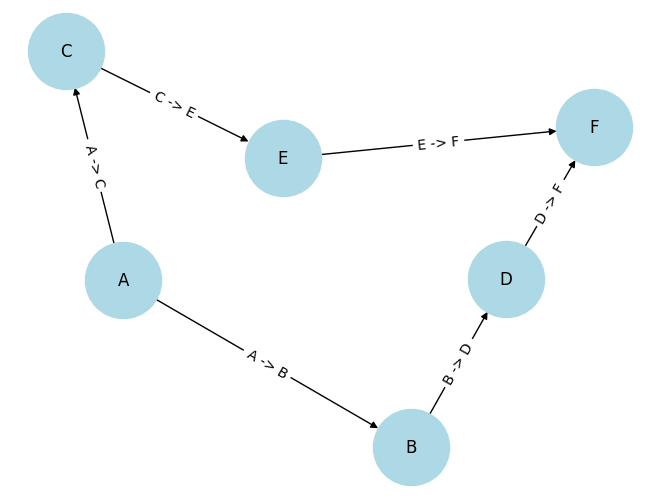

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

tsk = {
    'A': {'opt': 2, 'ml': 4, 'pes': 6, 'deps': []},
    'B': {'opt': 1, 'ml': 2, 'pes': 3, 'deps': ['A']},
    'C': {'opt': 1, 'ml': 3, 'pes': 5, 'deps': ['A']},
    'D': {'opt': 2, 'ml': 2, 'pes': 4, 'deps': ['B']},
    'E': {'opt': 3, 'ml': 5, 'pes': 7, 'deps': ['C']},
    'F': {'opt': 1, 'ml': 4, 'pes': 6, 'deps': ['D', 'E']}
}

for t, d in tsk.items():
  d['ed'] = (d['opt'] + 4 * d['ml'] + d['pes']) / 6
  d['var'] = ((d['pes'] - d['opt']) / 6) ** 2

g = nx.DiGraph()

for t, d in tsk.items():
  g.add_node(t, duration=d['ed'], variance=d['var'])

for t, d in tsk.items():
  for dp in d['deps']:
    g.add_edge(dp, t)

t_ord = list(nx.topological_sort(g))

es = {t: 0 for t in t_ord}
ef = {t: 0 for t in t_ord}

for t in t_ord:
  ef[t] = es[t] + g.nodes[t]['duration']
  for s in g.successors(t):
    es[s] = max(es[s], ef[t])

lf = {t: ef[t] for t in t_ord}
ls = {t: es[t] for t in t_ord}

for t in reversed(t_ord):
  for p in g.predecessors(t):
    lf[p] = min(lf[p], ls[t])
    ls[p] = lf[p] - g.nodes[p]['duration']

cp = [t for t in t_ord if es[t] == ls[t]]

pdur = ef[t_ord[-1]]
pvar = sum(g.nodes[t]['variance'] for t in cp)
psd = np.sqrt(pvar)

print('Earliest start times:', es)
print('Earliest finish times:', ef)
print('Latest start times:', ls)
print('Latest finish times:', lf)
print('Critical path:', cp)
print('Project duration (expected):', pdur)
print('Project standard deviation:', psd)

ps = nx.spring_layout(g)
nx.draw(g, ps, with_labels=True, node_size=3000, node_color='lightblue')
lbl = nx.get_node_attributes(g, 'duration')
nx.draw_networkx_edge_labels(g, ps, edge_labels={(u, v): f"{u} -> {v}" for u, v in g.edges})
plt.show()